# Project 12 -- Anthony Micco

**TA Help:** None

**Collaboration:** None

**Internet Resources:** None

**ChatGPT, Gemini, Claude, etc:** None

**Link to AI Chat History**: None

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [2]:
#reading in the data and combining all 50 datasets for each month
import pandas as pd
import glob
import os

data_path = os.path.expanduser("/anvil/projects/tdm/data/noaa_dtw/*.csv")

files = glob.glob(data_path)

print(f"Number of files found: {len(files)}")

dfs = []

for file in files:
    filename = os.path.basename(file).replace(".csv", "")
    state, capital = filename.split("_")

    df = pd.read_csv(
        file,
        usecols=["STATION", "DATE", "DailyAverageDryBulbTemperature"],
        engine="python",
        on_bad_lines="skip"
    )

    df["State"] = state
    df["Capital"] = capital

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

Number of files found: 50


,STATION,DATE,DailyAverageDryBulbTemperature,State,Capital
0,USW00023049,2024-01-01T00:00:00,1.2,NewMexico,SantaFe
1,USW00023049,2024-01-01T00:53:00,NaN,NewMexico,SantaFe
2,USW00023049,2024-01-01T01:53:00,NaN,NewMexico,SantaFe
3,USW00023049,2024-01-01T02:53:00,NaN,NewMexico,SantaFe
4,USW00023049,2024-01-01T03:53:00,NaN,NewMexico,SantaFe


In [3]:
#converting the DATE column to datetime and ensuring that DailyAverageDryBulbTemperature is numeric
combined_df["DATE"] = pd.to_datetime(combined_df["DATE"])
combined_df["DailyAverageDryBulbTemperature"] = pd.to_numeric(combined_df["DailyAverageDryBulbTemperature"],errors="coerce")
combined_df = (
    combined_df
    .sort_values(["State", "Capital", "DATE"]) 
    .reset_index(drop=True))

In [4]:
#displaying the first few values
combined_df.head(40)

,STATION,DATE,DailyAverageDryBulbTemperature,State,Capital
0,USW00013895,2024-01-01 00:00:00,NaN,Alabama,Montgomery
1,USW00013895,2024-01-01 00:00:00,8.1,Alabama,Montgomery
2,USW00013895,2024-01-01 00:53:00,NaN,Alabama,Montgomery
3,USW00013895,2024-01-01 01:53:00,NaN,Alabama,Montgomery
4,USW00013895,2024-01-01 02:53:00,NaN,Alabama,Montgomery
5,USW00013895,2024-01-01 03:00:00,NaN,Alabama,Montgomery
6,USW00013895,2024-01-01 03:53:00,NaN,Alabama,Montgomery
7,USW00013895,2024-01-01 04:53:00,NaN,Alabama,Montgomery
8,USW00013895,2024-01-01 05:53:00,NaN,Alabama,Montgomery
9,USW00013895,2024-01-01 06:00:00,NaN,Alabama,Montgomery


In [5]:
#rows with NaN values are all times except at midnight of the new day

In [6]:
#removing the missing temperature values from the dataset
cols_to_check = [
    col for col in combined_df.columns
    if col not in ["STATION", "DATE", "State", "Capital"]]

combined_df = combined_df.dropna(
    subset= cols_to_check,
    how="all")

combined_df.isna().sum()

STATION                           0
DATE                              0
DailyAverageDryBulbTemperature    0
State                             0
Capital                           0
dtype: int64

In [7]:
combined_df.head(20)

,STATION,DATE,DailyAverageDryBulbTemperature,State,Capital
1,USW00013895,2024-01-01,8.1,Alabama,Montgomery
34,USW00013895,2024-01-02,4.0,Alabama,Montgomery
67,USW00013895,2024-01-03,2.0,Alabama,Montgomery
107,USW00013895,2024-01-04,5.3,Alabama,Montgomery
156,USW00013895,2024-01-05,7.6,Alabama,Montgomery
285,USW00013895,2024-01-08,6.7,Alabama,Montgomery
336,USW00013895,2024-01-09,10.8,Alabama,Montgomery
406,USW00013895,2024-01-10,6.4,Alabama,Montgomery
439,USW00013895,2024-01-11,9.8,Alabama,Montgomery
472,USW00013895,2024-01-12,13.6,Alabama,Montgomery


In [8]:
#calculating the weekly average temperature for each state and capital
combined_df = (
    combined_df
    .set_index("DATE")
    .groupby(["State", "Capital"])["DailyAverageDryBulbTemperature"]
    .resample("W-SUN")
    .mean()
    .reset_index(name="WeeklyAvgTemp")
    .sort_values(["State", "Capital", "DATE"])
    .reset_index(drop=True)
)

combined_df["WeeklyAvgTemp"] = (
    combined_df
    .groupby(["State", "Capital"])["WeeklyAvgTemp"] # For YOU to fill in
    .ffill()
    .bfill()
)

In [9]:
#checking if any columns have missing values
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2650 entries, 0 to 2649
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   State          2650 non-null   object        
 1   Capital        2650 non-null   object        
 2   DATE           2650 non-null   datetime64[ns]
 3   WeeklyAvgTemp  2650 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 82.9+ KB


In [10]:
combined_df.head(20)

,State,Capital,DATE,WeeklyAvgTemp
0,Alabama,Montgomery,2024-01-07,5.400000
1,Alabama,Montgomery,2024-01-14,8.328571
2,Alabama,Montgomery,2024-01-21,1.928571
3,Alabama,Montgomery,2024-01-28,14.042857
4,Alabama,Montgomery,2024-02-04,9.714286
5,Alabama,Montgomery,2024-02-11,13.328571
6,Alabama,Montgomery,2024-02-18,10.614286
7,Alabama,Montgomery,2024-02-25,11.942857
8,Alabama,Montgomery,2024-03-03,15.385714
9,Alabama,Montgomery,2024-03-10,17.314286


1b) It is necessary to convert the date columns to the datetime type because we want to ensure all of time data is in the same format and can easily be plotted as time data in a time series plot. Additionally, we want to ensure that our temperature data is numeric because we do not want it to be confused with the datetime data and we want to be able to easily perform calculations with it.  

1c) We want to exclude any rows with no DailyAverageDryBulbTemperatures prior to time series modeling because we do not want gaps in our time series model if there is no data recorded at a specific time. By removing these rows, we will not have these gaps and our time series model will be smooth since each data point has temperature data.

## Question 2

In [11]:
#developing a function to randomly create a subset of x number of states
import numpy as np

def sample_states(df, n_states=5, seed=42):
    np.random.seed(seed)

    states = (
        df["State"]
        .drop_duplicates()
        .sample(n_states)
        .tolist()
    )

    return states

In [12]:
#selecting 5 random states
random_states = sample_states(combined_df, n_states=5)
random_states

['Iowa', 'SouthDakota', 'NewYork', 'Virginia', 'Maine']

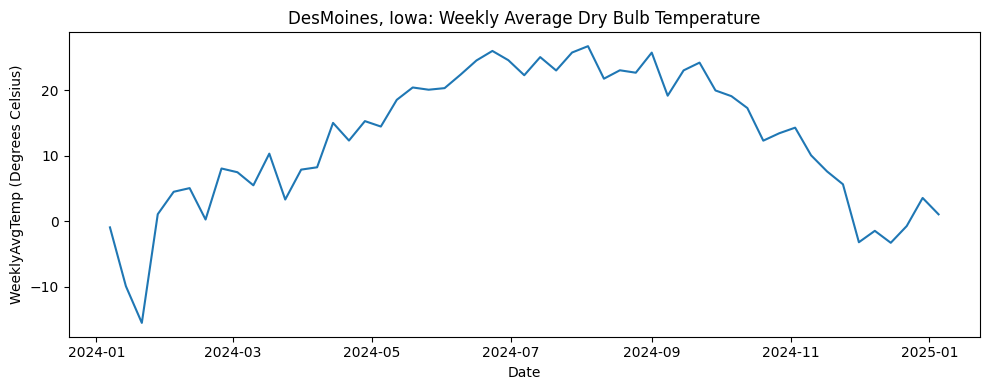

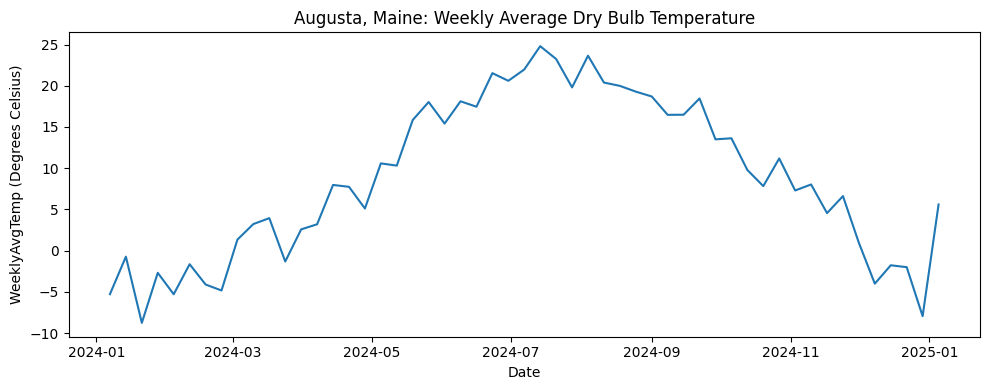

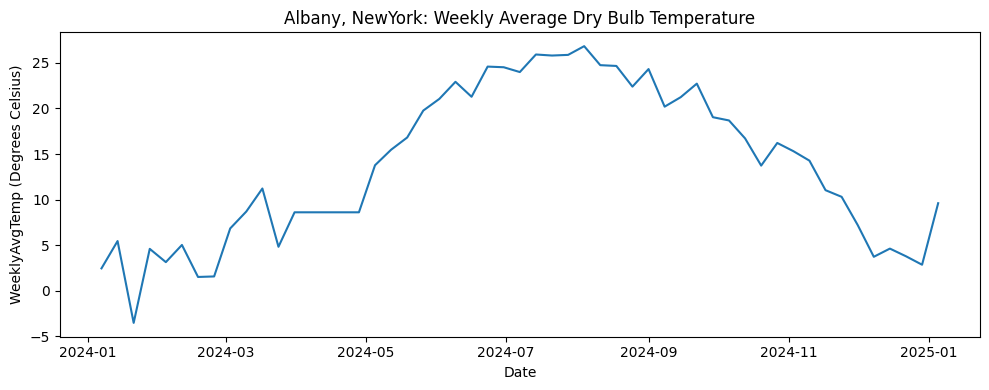

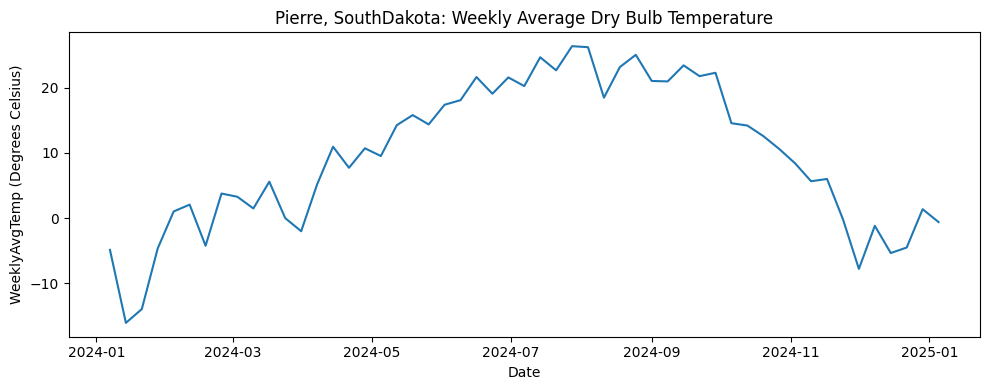

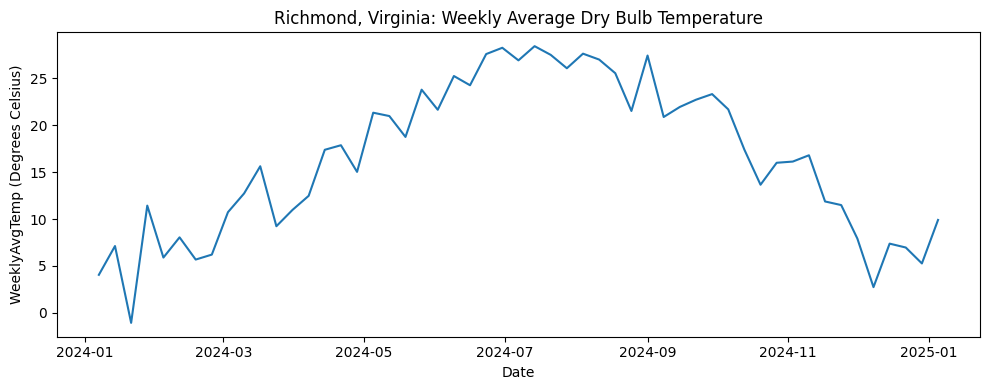

In [13]:
#plotting the weekly average dry bulb temperatures for our 5 random states
import matplotlib.pyplot as plt

plot_df = combined_df[combined_df["State"].isin(random_states)]

for (state, capital), group in plot_df.groupby(["State", "Capital"]):

    plt.figure(figsize=(10, 4))

    plt.plot(
        group["DATE"],
        group["WeeklyAvgTemp"])

    plt.xlabel("Date")
    plt.ylabel("WeeklyAvgTemp (Degrees Celsius)") 
    plt.title(f"{capital}, {state}: Weekly Average Dry Bulb Temperature")

    plt.tight_layout()
    plt.show()

In [14]:
#finding the total number of unique state,capital pairs in the dataset
n_series = (
    combined_df[["State", "Capital"]]
    .drop_duplicates()
    .shape[0])

n_series

50

2b) One of the similarties that clearly sticks out is the shape of the time-series curves for each of the states. All of the states have lower averages in the beginning of the year from January to about April, and then the temperature gradually increases as spring and summer start, before falling back down at the end of the year during fall and beginning of winter. However, one of the differences is the range of temperature averages for each state. For example, Pierre, South Dakota has an average temperature range of about -20 to 30 degrees, while Richmond, Virginia's range is from 0 to 30 degrees. This shows the geographic difference between the locations as it is typically warmer in Virginia all year, as compared to South Dakota. 

2c) There are 50 total unique series, one for each state. This count is important for later time-series analysis because it lets us know how many different time series we will be combining in our dynamic time warp for out final analysis, so it prepares us to consider how to structure our data.

## Question 3

In [15]:
#applying DTW to reshape the data to be indexed by State & Capital pairs
wide_df = combined_df.pivot_table(
    index=["State", "Capital"],
    columns="DATE",
    values="WeeklyAvgTemp"
)

In [16]:
wide_df.head()

,DATE,2024-01-07,2024-01-14,2024-01-21,2024-01-28,2024-02-04,2024-02-11,2024-02-18,2024-02-25,2024-03-03,2024-03-10,...,2024-11-03,2024-11-10,2024-11-17,2024-11-24,2024-12-01,2024-12-08,2024-12-15,2024-12-22,2024-12-29,2025-01-05
State,Capital,,,,,,,,,,,,,,,,,,,,,
Alabama,Montgomery,5.400000,8.328571,1.928571,14.042857,9.714286,13.328571,10.614286,11.942857,15.385714,17.314286,...,21.885714,23.600000,17.914286,13.571429,11.157143,6.314286,12.442857,11.300000,10.800000,14.75
Alaska,Juneau,-0.328571,-6.471429,-4.857143,1.085714,-0.214286,-0.814286,0.014286,1.114286,-6.971429,-1.757143,...,3.971429,4.300000,3.014286,-2.571429,-5.500000,2.271429,1.571429,-2.000000,3.400000,-3.35
Arizona,Phoenix,11.371429,9.100000,14.814286,15.200000,17.428571,12.485714,15.514286,19.714286,19.271429,17.728571,...,20.685714,16.628571,17.700000,17.628571,18.914286,19.042857,15.385714,17.328571,15.757143,15.60
Arkansas,LittleRock,3.914286,4.114286,-5.128571,9.871429,11.542857,13.042857,9.128571,14.542857,14.628571,16.185714,...,20.928571,18.957143,14.628571,13.128571,7.542857,4.628571,9.914286,8.171429,11.285714,10.30
Atlanta,Georgia,5.871429,7.300000,1.071429,12.657143,9.642857,12.271429,10.557143,11.885714,12.728571,15.428571,...,19.871429,19.814286,15.414286,12.885714,10.000000,5.500000,10.985714,10.614286,9.085714,14.70


In [17]:
#converting the wide table into a NumPy array and applying Z-Score normalization
import numpy as np

X = wide_df.values

X = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

In [18]:
X

array([[-1.93379829, -1.5375827 , -2.40345872, ..., -1.13556883,
        -1.20321539, -0.66880754],
       [-0.96965032, -1.94860046, -1.69134147, ..., -1.23601582,
        -0.37545036, -1.45115719],
       [-1.56417392, -1.81087603, -1.1902418 , ..., -0.91716273,
        -1.08783715, -1.10490459],
       ...,
       [-1.59030949, -1.34876245, -2.59534786, ..., -1.31329051,
        -0.93323398, -0.81837245],
       [-1.25521936, -1.60834922, -2.65326626, ..., -1.48243816,
        -1.0048445 , -0.98820109],
       [-1.2401423 , -2.42358556, -1.78302087, ..., -0.73089337,
        -0.76612443, -1.50357453]])

In [19]:
#clustering the normalized time-series using DTW and 4 clusters
from tslearn.clustering import TimeSeriesKMeans

n_clusters = 4

dtw_km = TimeSeriesKMeans(
    n_clusters=n_clusters,
    metric="dtw",
    random_state=42
)

labels = dtw_km.fit_predict(X)

cluster_df = wide_df.reset_index()[["State", "Capital"]].copy()
cluster_df["Cluster"] = labels

cluster_df.head()

/usr/local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


DATE,State,Capital,Cluster
0,Alabama,Montgomery,0
1,Alaska,Juneau,1
2,Arizona,Phoenix,1
3,Arkansas,LittleRock,3
4,Atlanta,Georgia,0


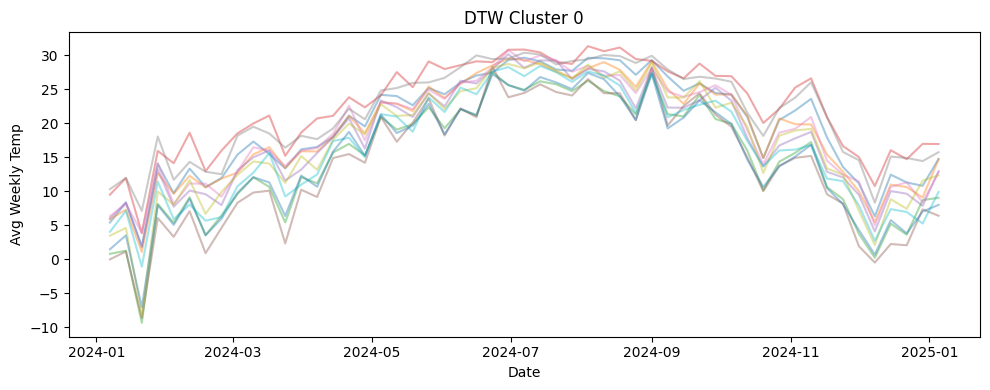

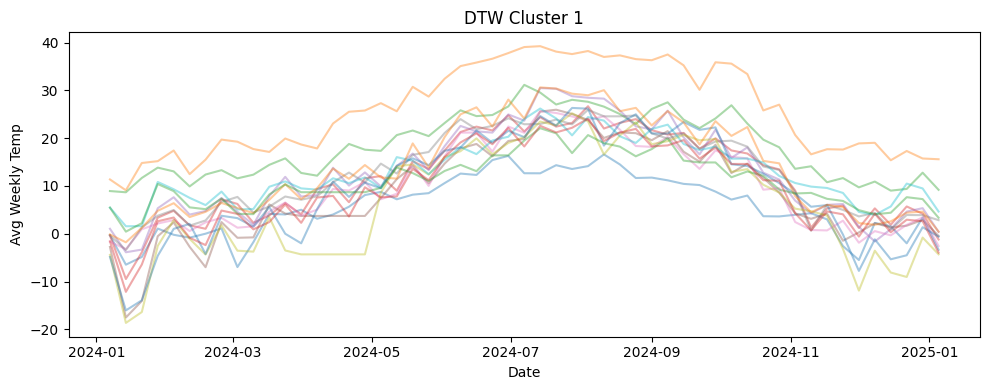

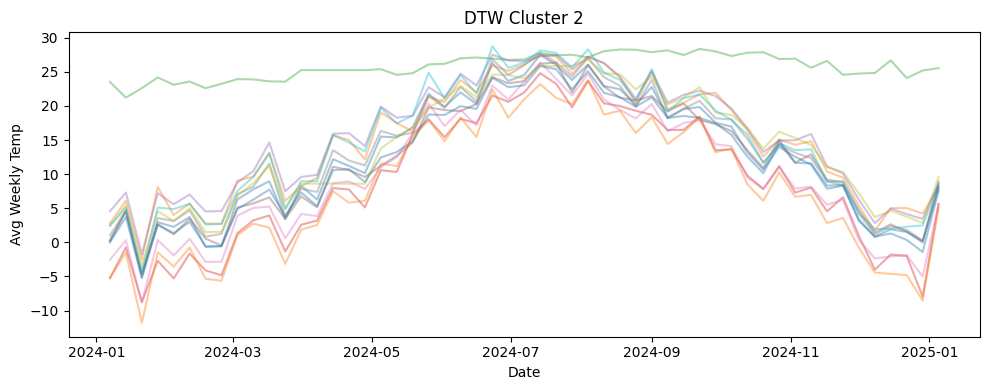

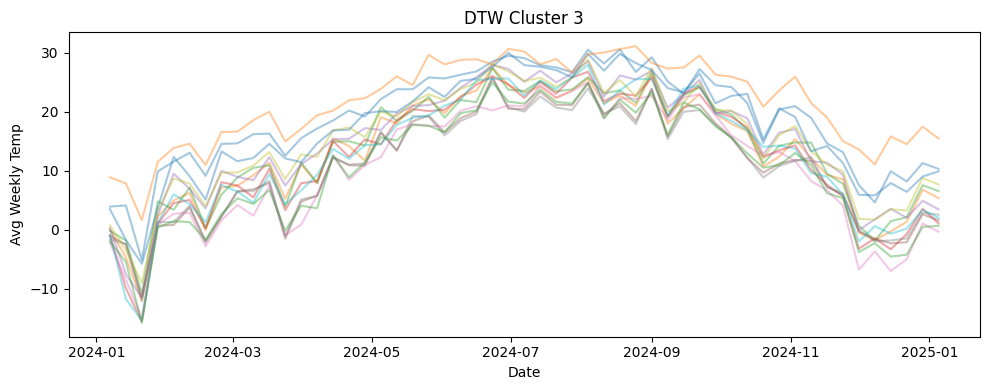

In [20]:
#plotting the member time-series data using the non-normalized temperature values
import matplotlib.pyplot as plt

dates = wide_df.columns        # calendar dates
wide_values = wide_df.values  # original (non-normalized) temperatures

for cluster in range(n_clusters):
    plt.figure(figsize=(10, 4))

    for i, label in enumerate(labels):
        if label == cluster:
            plt.plot(
                dates,
                wide_values[i],
                alpha=0.4
            )

    plt.title(f"DTW Cluster {cluster}")
    plt.xlabel("Date") 
    plt.ylabel("Avg Weekly Temp")
    plt.tight_layout()
    plt.show()

3c) DTW is used to group capitals into clusters by grouping states and capitals with similar temperature curves instead of values by using the dtw metric.

3d) One thing I notice about the clusters is that each State, Capital pair in each cluster share relatively the same pattern without any outliers, besides Cluster 2 and Cluster 1. Both of these clusters have one pair that has a noticeably higher average weekly temperature than the rest of the pairs and creates a gap between them. Outside of those couple clusters, the rest of clusters share similar patterns where they have the lowest temperatures at the beginning of the year, gradually increasing before peaking in July or August, and then decrease towards the end of the year. 

## Question 4

In [21]:
#creating a dataframe that contains one row per state and capital and its assigned DTW cluster
cluster_df = wide_df.reset_index()[["State", "Capital"]].copy() # For YOU to fill in
cluster_df["Cluster"] = labels

cluster_df.head()

DATE,State,Capital,Cluster
0,Alabama,Montgomery,0
1,Alaska,Juneau,1
2,Arizona,Phoenix,1
3,Arkansas,LittleRock,3
4,Atlanta,Georgia,0


In [22]:
#standarizing the names of the state names
state_name_fix = {
    "NewYork": "New York",
    "NewJersey": "New Jersey",
    "NewMexico": "New Mexico",
    "NewHampshire": "New Hampshire",
    "NorthCarolina": "North Carolina",
    "NorthDakota": "North Dakota",
    "SouthCarolina": "South Carolina",
    "SouthDakota": "South Dakota",
    "WestVirginia": "West Virginia",
    "RhodeIsland": "Rhode Island",
    "Atlanta": "Georgia",
    "Tallahassee": "Florida",
    "OklahomaCity": "Oklahoma"
}

def clean_state(s):
    return s.replace(state_name_fix).str.strip().str.title()

cluster_df["State"] = clean_state(cluster_df["State"])
combined_df["State"] = clean_state(combined_df["State"])

In [23]:
#adding geographic context to the data based on census regions

region_df = pd.DataFrame({
    "State": [
        # Northeast
        "Connecticut","Maine","Massachusetts","New Hampshire","Rhode Island",
        "Vermont","New Jersey","New York","Pennsylvania",
        # Midwest
        "Illinois","Indiana","Michigan","Ohio","Wisconsin","Iowa","Kansas",
        "Minnesota","Missouri","Nebraska","North Dakota","South Dakota",
        # South
        "Delaware","Florida","Georgia","Maryland","North Carolina","South Carolina",
        "Virginia","West Virginia","Alabama","Kentucky","Mississippi","Tennessee",
        "Arkansas","Louisiana","Oklahoma","Texas",
        # West
        "Arizona","Colorado","Idaho","Montana","Nevada","New Mexico","Utah",
        "Wyoming","Alaska","California","Hawaii","Oregon","Washington"
    ],
    "Region": (
        ["Northeast"] * 9 +
        ["Midwest"] * 12 +
        ["South"] * 16 +
        ["West"] * 13
    )
})

state_to_region = dict(zip(region_df["State"], region_df["Region"]))

combined_df["Region"] = combined_df["State"].map(state_to_region)

In [24]:
combined_df

,State,Capital,DATE,WeeklyAvgTemp,Region
0,Alabama,Montgomery,2024-01-07,5.400000,South
1,Alabama,Montgomery,2024-01-14,8.328571,South
2,Alabama,Montgomery,2024-01-21,1.928571,South
3,Alabama,Montgomery,2024-01-28,14.042857,South
4,Alabama,Montgomery,2024-02-04,9.714286,South
...,...,...,...,...,...
2645,Wyoming,Cheyanne,2024-12-08,4.200000,West
2646,Wyoming,Cheyanne,2024-12-15,0.314286,West
2647,Wyoming,Cheyanne,2024-12-22,2.942857,West
2648,Wyoming,Cheyanne,2024-12-29,2.628571,West


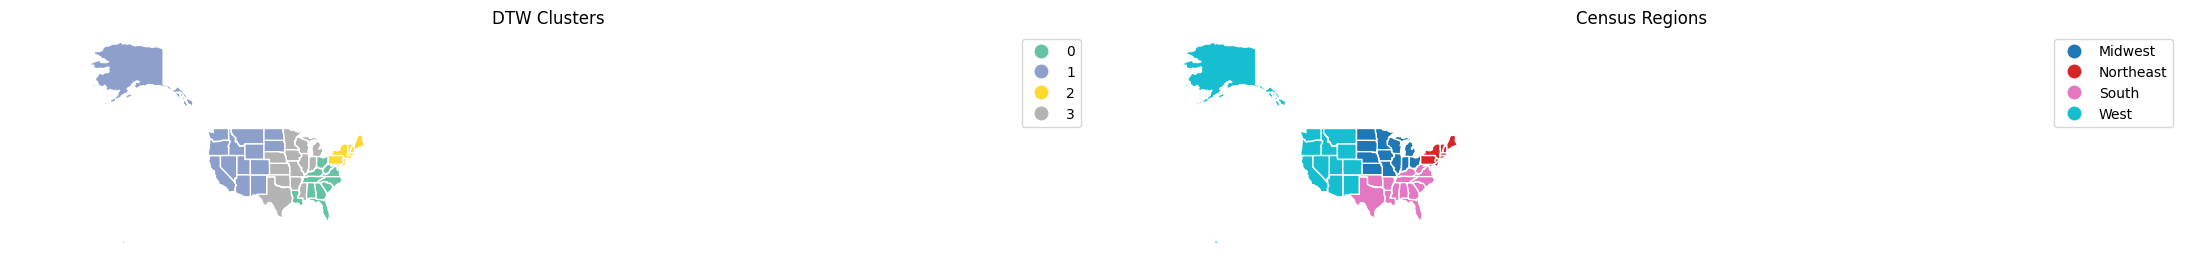

In [25]:
#visualiing the DTW clusters and US Census regions in side-by-side maps
import geopandas as gpd
import matplotlib.pyplot as plt

state_summary = cluster_df[["State", "Cluster"]].merge(
    combined_df[["State", "Region"]].drop_duplicates(),
    on="State",
    how="left"
)

us_states = (
    gpd.read_file(
        "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"
    )
    .query("STUSPS not in ['PR','VI','GU','MP','AS','DC']")
    .assign(State=lambda df: df["NAME"].str.strip().str.title())
)

map_df = us_states.merge(state_summary, on="State", how="left")

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

map_df.plot(column="Cluster", categorical=True, cmap="Set2",
            legend=True, edgecolor="white", ax=axes[0])
axes[0].set_title("DTW Clusters")
axes[0].axis("off")

map_df.plot(column="Region", categorical=True, cmap="tab10",
            legend=True, edgecolor="white", ax=axes[1])
axes[1].set_title("Census Regions")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [26]:
#merging DTW clusters with the weekly temperature dataset
df_labeled = combined_df.merge(
    cluster_df[["State", "Capital", "Cluster"]],
    on=["State", "Capital"], 
    how="inner")

In [27]:
df_labeled

,State,Capital,DATE,WeeklyAvgTemp,Region,Cluster
0,Alabama,Montgomery,2024-01-07,5.400000,South,0
1,Alabama,Montgomery,2024-01-14,8.328571,South,0
2,Alabama,Montgomery,2024-01-21,1.928571,South,0
3,Alabama,Montgomery,2024-01-28,14.042857,South,0
4,Alabama,Montgomery,2024-02-04,9.714286,South,0
...,...,...,...,...,...,...
2645,Wyoming,Cheyanne,2024-12-08,4.200000,West,1
2646,Wyoming,Cheyanne,2024-12-15,0.314286,West,1
2647,Wyoming,Cheyanne,2024-12-22,2.942857,West,1
2648,Wyoming,Cheyanne,2024-12-29,2.628571,West,1


4c) It is informative to compare DTW-base temperature clusters with traditional Census regional groupings because it will group states with similar climates. This enables the DTW-base temperature clusters to be closely related and avoid any significant outliers.  

4d) A lot of the states in DTW clusters and the US Census regions align quite well, but there are some slight mismatches. One of these mismatches is that Texas, Oklahoma, Arkansas, and Mississippi are all in cluster 3, which includes most of the states in the midwest region, but they are considered the south region. Another mismatch is the addition of North and South Dakota to cluster 1, which includes all of the states in the west region, even though they are considered midwest states. Finally, cluster 2 is perfectly aligned with the northeast region from the US census data.

## Question 5

In [28]:
#splitting the time series data into train and test
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)

    df_labeled = (
        df_labeled
        .sort_values(["State", "Capital", "DATE"])
        .reset_index(drop=True))

    train_df = (
        df_labeled
        .groupby(["State", "Capital"], group_keys=False)
        .apply(lambda g: g.iloc[:-4])
        .reset_index(drop=True))

    test_df = (
        df_labeled
        .groupby(["State", "Capital"], group_keys=False)
        .apply(lambda g: g.iloc[-4:])
        .reset_index(drop=True))

In [30]:
df_labeled.shape

(2650, 6)

In [31]:
train_df.shape

(2450, 6)

In [32]:
test_df.shape

(200, 6)

In [33]:
#fitting a standardized "average shape" for each DTW cluster
import numpy as np

capital_scale = {}
cluster_shapes = {}

for cluster, grp in train_df.groupby("Cluster"):
    z_series = []

    for (state, capital), g in grp.groupby(["State", "Capital"]):
        y = g.set_index("DATE")["WeeklyAvgTemp"].asfreq("W-SUN").interpolate()

        mu, sigma = y.mean(), y.std(ddof=0)
        if sigma > 0:
            capital_scale[(state, capital)] = (mu, sigma)
            z_series.append((y - mu) / sigma)

    cluster_shapes[cluster] = pd.concat(z_series, axis=1).mean(axis=1)

In [34]:
#fitting a separate model for each capital using a SARIMAX model
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

# Grid over non-seasonal ARIMA parameters
param_grid = list(itertools.product([0, 1, 2], [0, 1], [0, 1, 2]))
best_cluster_params = {}

for cluster, z in cluster_shapes.items():
    z = z.asfreq("W-SUN").interpolate()
    z_train, z_val = z.iloc[:-4], z.iloc[-4:]

    best_score, best_cfg = np.inf, None

    for order in param_grid:
        try:
            res = SARIMAX(
                z_train,
                order=order,
                # Annual seasonality fixed using domain knowledge
                seasonal_order=(0, 1, 0, 52),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            preds = res.get_forecast(4).predicted_mean
            score = rmse(z_val, preds)

            if score < best_score:
                best_score, best_cfg = score, order

        except Exception:
            continue

    best_cluster_params[cluster] = best_cfg
    print(f"Cluster {cluster}: RMSE={best_score:.3f}, order={best_cfg}")

Cluster 0: RMSE=1.237, order=(0, 0, 0)
Cluster 1: RMSE=0.288, order=(0, 1, 0)
Cluster 2: RMSE=0.834, order=(0, 1, 0)
Cluster 3: RMSE=0.984, order=(0, 1, 0)


In [44]:
#generating forecasts for each capital's heldout period using the SARIMAX models
predictions = {}

for (state, capital), g in train_df.groupby(["State", "Capital"]):
    cluster = int(g["Cluster"].iloc[0])

    if (state, capital) not in capital_scale:
        continue

    mu, sigma = capital_scale[(state, capital)]
    z = cluster_shapes[cluster]

    model = SARIMAX(
        z,
        order=best_cluster_params[cluster],
        seasonal_order=(0, 1, 0, 52),
        enforce_stationarity=False,
        enforce_invertibility=False).fit(disp=False)

    y_test = (
        test_df
        .query("State == @state and Capital == @capital")
        .set_index("DATE")["WeeklyAvgTemp"]
        .asfreq("W-SUN")
        .interpolate())

    z_pred = model.get_forecast(len(y_test)).predicted_mean
    predictions[(state, capital)] = (y_test, z_pred * sigma + mu)

rmse_df = pd.DataFrame([
    {
        "State": s,
        "Capital": c,
        "Cluster": train_df.query(
            "State == @s and Capital == @c"
        )["Cluster"].iloc[0],
        "RMSE": rmse(y.values, yhat.values)
    }
    for (s, c), (y, yhat) in predictions.items()])

top3 = rmse_df.nsmallest(3, "RMSE")

In [52]:
rmse_df["RMSE"].sort_values(ascending=False).value_counts()

RMSE
10.401835    1
9.890231     1
9.653683     1
9.555820     1
9.457232     1
9.456264     1
9.144602     1
9.121735     1
9.087681     1
8.838341     1
8.632351     1
8.517274     1
8.378075     1
8.374211     1
8.099531     1
8.043830     1
7.919197     1
7.862675     1
7.771042     1
7.700582     1
7.522677     1
7.508946     1
7.501673     1
7.430919     1
7.328959     1
7.259988     1
7.182704     1
6.950028     1
6.935711     1
6.853135     1
6.837347     1
6.719315     1
6.560140     1
6.411538     1
6.165557     1
6.098288     1
5.956567     1
5.779784     1
3.613014     1
3.537787     1
3.077259     1
3.061464     1
2.892358     1
2.662415     1
2.656681     1
2.538673     1
2.537608     1
2.386124     1
2.186824     1
1.848058     1
Name: count, dtype: int64

In [41]:
top3

,State,Capital,Cluster,RMSE
46,Washington,Olympia,1,1.848058
49,Wyoming,Cheyanne,1,2.186824
27,Nevada,CarsonCity,1,2.386124


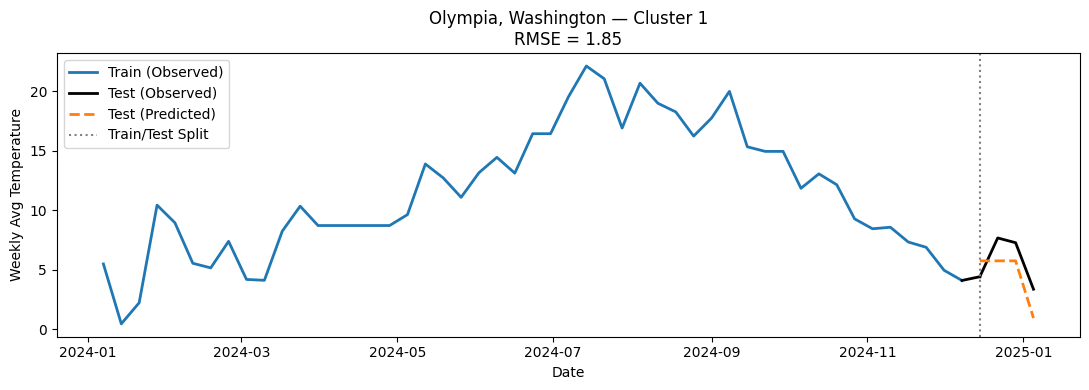

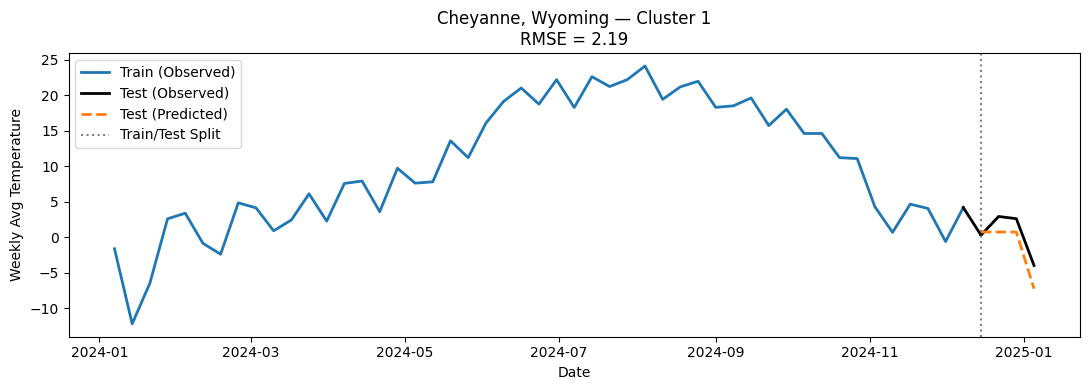

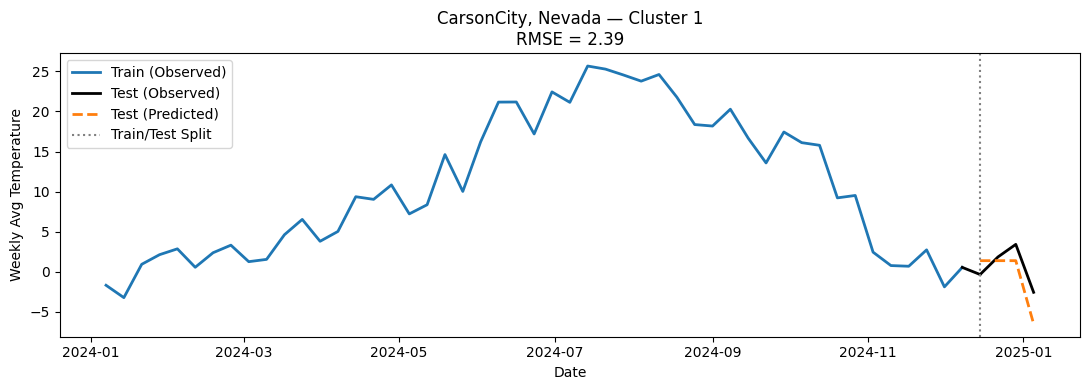

In [43]:
#plotting the test-set forecasts for selected capitals from different DTW clusters
import matplotlib.pyplot as plt

for _, row in top3.iterrows():

    state   = row["State"]
    capital = row["Capital"]
    cluster = int(row["Cluster"])
    score   = row["RMSE"]

    train_obs = (
        train_df
        .query("State == @state and Capital == @capital")
        .set_index("DATE")["WeeklyAvgTemp"]
        .asfreq("W-SUN")
        .interpolate())

    test_obs = (
        test_df
        .query("State == @state and Capital == @capital")
        .set_index("DATE")["WeeklyAvgTemp"]
        .asfreq("W-SUN")
        .interpolate())

    _, y_pred = predictions[(state, capital)]

    plt.figure(figsize=(11, 4))

    # Training observations
    plt.plot(train_obs, label="Train (Observed)", linewidth=2)

    # Explicit connection from train → test
    plt.plot(
        [train_obs.index[-1], test_obs.index[0]],
        [train_obs.iloc[-1], test_obs.iloc[0]],
        color="black",
        linewidth=2)

    # Test observations
    plt.plot(test_obs, label="Test (Observed)", color="black", linewidth=2)
    # Test predictions
    plt.plot(y_pred, "--", linewidth=2, label="Test (Predicted)")

    # Train/test split marker
    plt.axvline(
        test_obs.index.min(),
        color="gray",
        linestyle=":",
        label="Train/Test Split")
    plt.title(f"{capital}, {state} — Cluster {cluster}\nRMSE = {score:.2f}")
    plt.xlabel("Date")
    plt.ylabel("Weekly Avg Temperature")
    plt.legend()
    plt.tight_layout()
    plt.show()

5b) Creating a standardized “average shape” at the cluster level helps capture common temperature dynamics across capitals because it gives each related state, capital pair a shared shape that each element of the cluster can relate to. This is preferable to modeling each independently because there may be far more outliers if we modeled 50 different capitals independently as opposed to clustering them and modeling related capitals together. 

5c) The first $0$ in the seasonal_order is the autoregressive order and impacts how many past values of the time series will be used to predict future values. The $1$ in the seasonal_order is the seasonal differencing order value and a value of 1 removes yearly seasonality when using weekly data. The second $0$ in the seasonal_order is the moving average order value and helps capture noise in the data. Finally, the last value, $52$, in the seasonal order is the seasonal period and represents how many observations are in one seasonal cycle. The value $52$ makes sense for the weekly temperature pattern data because there are $52$ weeks in a year, so it makes sense to use $52$ since we have weekly data for a singular year.

5d) In general, we want to minimize RMSE when analyzing the performance of a model as it calculates the average sum of the model's errors, so a lower RMSE indicates strong model performance. For the most part, our model produced lower RMSE values as the largest RMSE value was only approximately 10.402, so it performed strongly. Every other capital's RMSE was less than 10 and the best performing model, Olympia, Washington, had an RMSE of 1.848.  

5e) From the graphs, it appears as if smoother graphs indicate better performance as the Olympia, Washington graph as the smoothest curve and also has the lowest RMSE. Strong performance is also indicated when the observed test data curve is close to the predicted test curve as it shows that the predictions closely followed what the actual values were.  

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
